In [1]:
import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from dipy.segment.mask import median_otsu
from torch.utils.data import Dataset, DataLoader
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import time

c:\Users\Acer\Desktop\Saroj_Project\IVIM_Autoencoder\ivimvnv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

Training on: cuda


In [3]:
pip show torch

Name: torch
Version: 2.8.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: c:\users\acer\desktop\saroj_project\ivim_autoencoder\ivimvnv\lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, sympy, typing-extensions
Required-by: monai, torchaudio, torchvision
Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
print(torch.__version__)              # Should show +cu128 (not +cpu)
print(torch.cuda.is_available())      # Should be True
print(torch.cuda.get_device_name(0))  # Should show "NVIDIA GeForce GTX 1650 Ti"
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

2.8.0+cu128
True
NVIDIA GeForce GTX 1650 Ti
VRAM: 4.29 GB


In [5]:
import subprocess

try:
    result = subprocess.run(
        ["nvidia-smi"],
        capture_output=True,
        text=True,
        check=True
    )
    print(result.stdout)
except FileNotFoundError:
    print("nvidia-smi is not installed or not on PATH.")
except subprocess.CalledProcessError as exc:
    print("nvidia-smi failed:", exc.stderr or exc)

Sun Aug  2 08:23:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.44                 Driver Version: 591.44         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650 Ti   WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   46C    P8              4W /   30W |     136MiB /   4096MiB |      4%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
## Loading data
path = r"C:\Users\Acer\Desktop\Saroj_Project\IVIM_Autoencoder\notebooks\BRAIN"

raw_data=nib.load(path+"\data.nii.gz")
mri_data=raw_data.get_fdata()
print(mri_data.shape)

(256, 256, 54, 21)


## **Data description**
1. H: Height of one image in the sequence
2. W: Width of one image in the sequence
3. D: Depth of images or Number of images in the sequence
4. C: Number of channels (like 3 RGB or b-values)

In [7]:
# data = torch.randn(2,3,4,4)
# data.shape
# data[0]
# plt.imshow(data[0])

In [10]:
##Data Splitting 70% for train and 30% for test data
slice_indx=int(0.8*mri_data.shape[2])
val_indx = int(0.70*slice_indx)
##train and test
train = mri_data[:,:,:val_indx,:]
val = mri_data[:, :, val_indx:slice_indx, :]
test = mri_data[:,:,slice_indx:,:]

In [11]:
train.shape, val.shape, test.shape

((256, 256, 30, 21), (256, 256, 13, 21), (256, 256, 11, 21))

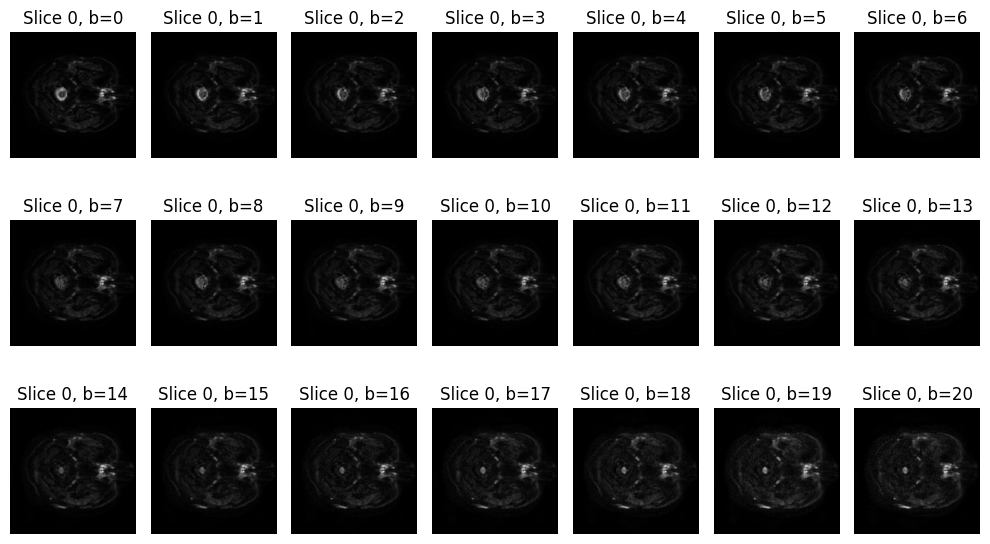

In [12]:
##displaying the 2 slice of mri data over 21 b-value
fig, ax = plt.subplots(3,7, figsize=(10,6))

# Flatten the 2D array of axes into a 1D array for easier iteration
flat_axes = ax.ravel()

plot_counter = 0
# Iterate over the first two slices (depth dimension) of the MRI data
for i in range(train[:,:,:2,:].shape[2]):
  # Iterate over all b-values
  for j in range(train.shape[3]): # j will be 0 to 20 b-values
    if plot_counter < len(flat_axes): # Check if there are still subplots available
      current_ax = flat_axes[plot_counter]
      current_ax.imshow(train[:,:,i,j], cmap='gray')
      current_ax.set_title(f"Slice {i}, b={j}") # Add a title for context
      current_ax.axis('off') # Turn off axis labels for cleaner display
      plot_counter += 1

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()

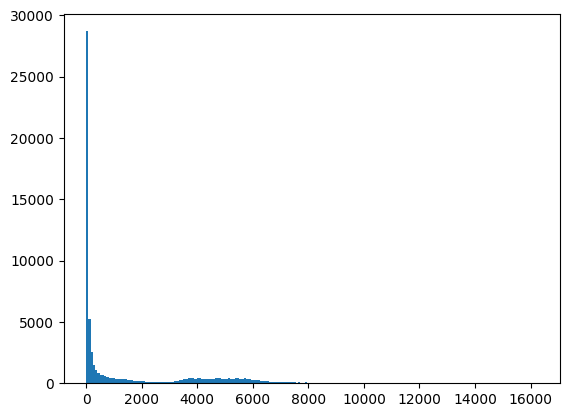

In [13]:
img = train[:,:,20,0]
#for standardize the pixel values
# mean = np.mean(img)
# std = np.std(img)
# img = img-mean
# img = img/std
plt.hist(img.flatten(),bins=200)
plt.show()


In [14]:
# Extract b0 directly from raw mri_data (H, W, D, b) order — no transpose needed
b0_raw = train[:,:, 0]  # shape (256, 256, 54) = (H, W, D)

_, otsu_mask = median_otsu(b0_raw, median_radius=3, numpass=2)
brain_msk = otsu_mask.astype(np.uint8)   #shape (256, 256, 54) = (H, W, D)

print("Mask shape (H, W, b-value):", brain_msk.shape)  #(256, 256, 54)

Mask shape (H, W, b-value): (256, 256, 21)


In [15]:
d=train[:,:,2,:]
print(f"data shape {np.transpose(d, (2,0,1)).shape}")
print(f"Mask shape {np.transpose(brain_msk).shape}")

data shape (21, 256, 256)
Mask shape (21, 256, 256)


## **DATA PREPROCESSING FOR SIMILAR NEIGHBOURING PIXELS EXTRACTION**

In [16]:
def process_chunk(padded_px, padded_b0, y, x, dy, dx,
                    center_flat_idx, target_slots, b_value):
    """
    Broadcasting Technique:
      Vectorized core, run on one chunk of pixels at a time so peak memory
    stays bounded regardless of total voxel count N.
    """
    n = len(y)

    ##Broadcasting technique to speed up the calculation
    # Build 5x5 neighborhood (25 positions per pixel) fetch using 5x5 window
    yy = y[:, None] + dy[None, :]
    xx = x[:, None] + dx[None, :]

    ##similar neighbouring pixels calculation
    b0_neighbors = padded_b0[yy, xx]              # (n, 25)
    center_b0 = padded_b0[y, x]                     # (n,)
    similarity = np.abs(center_b0[:, None] - b0_neighbors)  # (n, 25)

    ##a masking array of 25 boolean coordinate
    keep = np.ones(25, dtype=bool)

    ##removing center coordinate from the extracted 5x5 similarity matrix
    keep[center_flat_idx] = False

    ##indexing drops/remove center from the column where keep==false
    similarity = similarity[:, keep] # (n, 24)

    # Drops the center coordinates
    yy, xx = yy[:, keep], xx[:, keep]

    #Stable sort to match Python's stable list.sort()
    order = np.argsort(similarity, axis=1, kind='stable')  # (n, 24)

    ##order indices says which column to pick per row
    top8_indices = order[:, :8]

    ##selects values from an array along a specified axis using index arrays
    yy_top = np.take_along_axis(yy, top8_indices, axis=1)      # (n, 8)
    xx_top = np.take_along_axis(xx, top8_indices, axis=1)
    full_top8 = padded_px[:, yy_top, xx_top]  # (b_value, n, 8)

    ##initialize the 3x3 patch of most similar pixels
    block = np.zeros((n, 3, 3, b_value), dtype=np.float32)
    center_vals = padded_px[:, y, x]             # (b_value, n)
    block[:, 1, 1, :] = center_vals.T

    vals = np.transpose(full_top8, (1, 2, 0))           # (n, 8, b_value)
    block[:, target_slots[:, 0], target_slots[:, 1], :] = vals

    return block

In [17]:
def similar_neighborhood_patch(data, brain_masker, chunk_size=20000):
    """
    For each depth slice, extracts every brain pixels 5x5 neighborhood, selects
    the 8 pixels most similar to the center in b0-intensity, and packs them
    (in similarity-rank order) into a 3x3 block with the center pixel at (1,1).

    Processes voxels in chunks of `chunk_size` to bound peak memory.

    Parameters
    ----------
    mri_data : ndarray, shape (H, W, D, Num_b)
        4D MRI data with spatial dimensions Height, Width, Depth and
        Num_b b-value measurements. The first measurement (index 0) is
        assumed to be the b=0 image.
    brain_mask : ndarray, shape (H, W, b-value)
        3D binary brain mask. pixels with value > 0 are considered brain.
    b0_threshold : float, default 1.0
        Minimum b0 intensity for a pixels to be included. pixels with
        b0_image < b0_threshold are excluded even if inside the mask.
    chunk_size : int, default 20000
        Number of pixel processed per chunk to limit memory usage.
    """
    ##Shape of the raw data
    H, W, D, b_value = data.shape

    ##x and y factors to normalize the coordinates
    y_factor = 2.0 / (H - 1) if H > 1 else 1.0
    x_factor = 2.0 / (W - 1) if W > 1 else 1.0

    ##initializing empty list for the final data
    similar_patch, center_coord, norm_cent_coord  = [], [], []

    ##2D slices from the 3D MRI data
    for i in range(data.shape[2]):
      slices_data = data[:,:,i,:]

      ##pytorch convention (Channel, H,W,D)
      mri_slice = np.transpose(slices_data, (2, 0, 1))  # (b, H, W)


      # brain_mask must be transposed the same way as mri_data,
      brain_mask_slice = np.transpose(brain_masker, (2,0,1)) # (b, H, W)

      ##mean of valid brain intensity
      b0_img_mean = np.mean(brain_mask_slice>0)

      ##threshold
      b0_threshold = 0.50*b0_img_mean

      ##first image at b-value=0
      b0_image = mri_slice[0]

      ##brain indices selects the brain pixels to process
      brain_indices = np.argwhere((brain_mask_slice > 0) & (b0_image >= b0_threshold))
      N = len(brain_indices)
      print(f"Processing {N} brain pixel to build 2D similarity blocks...")

      ##padding tensors
      padded_px = np.pad(mri_slice, ((0, 0), (2, 2), (2, 2)), mode='constant', constant_values=0)
      ##padded signal at b-value=0
      padded_b0 = padded_px[0]

      ##x and y coordinates of brain indices with padding
      y_all = (brain_indices[:, 0] + 2).astype(np.int32)
      x_all = (brain_indices[:, 1] + 2).astype(np.int32)

      ##array ranging from -2 to 3, for generating a 5x5 window: array([-2, -1,  0,  1,  2])
      offs = np.arange(-2, 3, dtype=np.int32)

      ##5x5 window matrix
      dy, dx = np.meshgrid(offs, offs, indexing='ij')
      ##flatten them in 1d array
      dy, dx = dy.ravel(), dx.ravel()
      ##offset coordinate index for central pixel
      center_flat_idx = 12  #(0,0) offset's position in the flatten 25-length grid

      ##initialize the empty neighbors slot to store top neighbor pixels later in calculation
      top_neighbors_slot = np.array([
          (a, b) for a in range(3) for b in range(3) if not (a == 1 and b == 1)
      ])  #(8, 2)

      ##initialize the empty similar neighbourhood block array
      similar_neig_block = np.zeros((N, 3, 3, b_value), dtype=np.float32)

      ##actual similar neighbourhood data calculated in chunks and store in pre-defined similar_neig_block
      for start in range(0, N, chunk_size):
          end = min(start + chunk_size, N)
          similar_neig_block[start:end] = process_chunk(padded_px, padded_b0, y_all[start:end], x_all[start:end],
                                                    dy, dx, center_flat_idx, top_neighbors_slot, b_value)

      center_coords = list(map(tuple, brain_indices))
      y0 = brain_indices[:, 0] * y_factor - 1.0
      x0 = brain_indices[:, 1] * x_factor - 1.0
      center_norm_coord = list(zip(y0.tolist(), x0.tolist()))

      similar_patch.append(similar_neig_block)
      center_coord.append(center_coords)
      norm_cent_coord.append(center_norm_coord)
    print("Processing completed.")
    return similar_patch, center_coord, norm_cent_coord

In [18]:
# Load b-values from the file
with open(path+"/bvalues.bval", "r") as f:
    bvals_str = f.read().split()
bvals_arr = np.array([float(b) for b in bvals_str], dtype=np.float32)

print(f"Loaded b-values: {bvals_arr}")
print(f"Number of b-values (N_b): {len(bvals_arr)}")

Loaded b-values: [   0.   10.   20.   30.   40.   60.   80.  100.  120.  140.  160.  180.
  200.  300.  400.  500.  600.  700.  800.  900. 1000.]
Number of b-values (N_b): 21


In [19]:
# Now this matches what similar_neighborhood_3d_fast expects internally:
similar_patch, coords, norm_coords = similar_neighborhood_patch(
    train, brain_msk)

Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity bl

In [20]:
# Run similar_neighborhood_search with actual MRI data
print(f"Extracted {len(similar_patch)} patches from real data")
print("Example block shape:", similar_patch[1].shape)
# print("Example normalised coordinate:", norm_coords[0])

Extracted 30 patches from real data
Example block shape: (119110, 3, 3, 21)


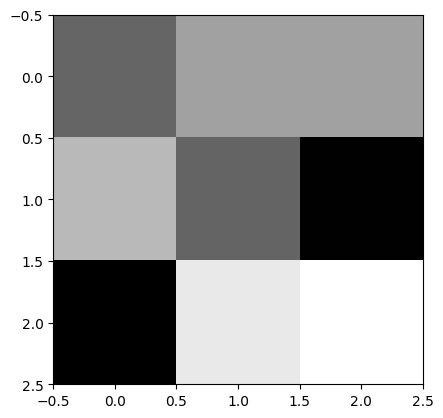

In [21]:
##display 3x3 block
plt.imshow(similar_patch[0][0,:,:,0], cmap='gray') # Display the signal at 21 b-value of the first block's middle depth slice
plt.show()

In [22]:
similar_patch[0] ##shape=(119110, 3, 3, 21)

array([[[[2.8211887 , 3.1172276 , 2.98289   , ..., 1.2036138 ,
          2.286937  , 0.989989  ],
         [3.1805973 , 2.9314415 , 1.6534989 , ..., 1.9119836 ,
          3.049398  , 0.9762305 ],
         [3.1818972 , 1.0095345 , 1.8281806 , ..., 0.7212294 ,
          2.005823  , 2.1241398 ]],

        [[3.3235292 , 2.0790048 , 2.0925772 , ..., 1.6540359 ,
          2.3005352 , 1.4158802 ],
         [2.8150687 , 2.1669722 , 2.326834  , ..., 1.2111448 ,
          1.474758  , 2.3251648 ],
         [2.2329834 , 1.0168543 , 0.8850659 , ..., 1.514229  ,
          1.2453593 , 0.2645388 ]],

        [[2.2220192 , 1.969489  , 2.3891058 , ..., 1.1732019 ,
          1.4794588 , 2.0373309 ],
         [3.6055262 , 2.8659139 , 3.2242954 , ..., 1.1898456 ,
          2.3528323 , 1.2947432 ],
         [3.7393415 , 0.13221131, 0.89367425, ..., 0.98447764,
          1.7214471 , 0.94328636]]],


       [[[2.8211887 , 3.1172276 , 2.98289   , ..., 1.2036138 ,
          2.286937  , 0.989989  ],
         [3.

In [23]:
x=torch.from_numpy(similar_patch[0]).float()
x.shape

torch.Size([119110, 3, 3, 21])

In [24]:
##shape=(119110, 3, 3, 21) -----> shape=(119110, 21, 3, 3) ----> Idx shape=(0, 3, 1, 2)
x1=x.permute(0, 3, 1, 2) 
x1.shape

torch.Size([119110, 21, 3, 3])

In [25]:
print(x1[:,0:1, :, : ])
x1[:, 0:1, :, : ].shape ##torch.Size([21, 3, 3])

tensor([[[[2.8212, 3.1806, 3.1819],
          [3.3235, 2.8151, 2.2330],
          [2.2220, 3.6055, 3.7393]]],


        [[[2.8212, 3.1806, 3.1819],
          [3.3235, 2.8151, 2.2330],
          [2.2220, 3.6055, 3.7393]]],


        [[[2.8212, 3.1806, 3.1819],
          [3.3235, 2.8151, 2.2330],
          [2.2220, 3.6055, 3.7393]]],


        ...,


        [[[3.6661, 3.2641, 3.8467],
          [3.8766, 3.4869, 4.1104],
          [2.8595, 4.1367, 4.3691]]],


        [[[3.6661, 3.2641, 3.8467],
          [3.8766, 3.4869, 4.1104],
          [2.8595, 4.1367, 4.3691]]],


        [[[3.6661, 3.2641, 3.8467],
          [3.8766, 3.4869, 4.1104],
          [2.8595, 4.1367, 4.3691]]]])


torch.Size([119110, 1, 3, 3])

In [26]:
x1[:,0:1,:,:][0].shape

torch.Size([1, 3, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.2220192..3.7393415].


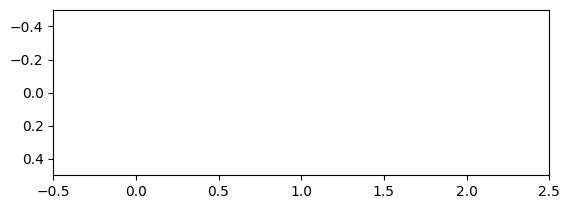

In [27]:
##b0_image
plt.imshow(x1[:, 0:1, :, :][0], cmap='gray')
plt.show()

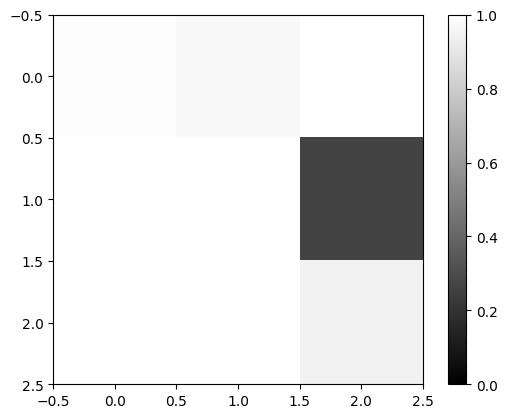

In [28]:
# Visualise the highest b-value (e.g., index -1), with non-zero b-value
plt.imshow(x1[0, -1, :, :], cmap="gray", vmin=0, vmax=1)
plt.colorbar()
plt.show()

In [29]:
len(norm_coords)

30

## **DATASET**

In [30]:
# Test a batch from the real data dataloader
class DiffusionDataset(Dataset):
    def __init__(self, similar_patches, condition):
        self.patches = similar_patches
        self.condition = condition

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.patches[idx]).float()

        # For a single patch, shape is typically (3, 3, b-values)
        # and should become (b-values, 3, 3) for the model.
        # If a batch is passed in instead, keep the batch dimension first.
        if x.dim() == 3:
            x = x.permute(2, 0, 1)
        elif x.dim() == 4:
            x = x.permute(0, 3, 1, 2)
        else:
            raise ValueError(f"Unexpected tensor shape {tuple(x.shape)}")

        y = torch.tensor(self.condition[idx]).float()
        return x, y

In [31]:
np.array([item for sublist in norm_coords for item in sublist])

array([[-1.        , -0.6       ],
       [-1.        , -0.6       ],
       [-1.        , -0.6       ],
       ...,
       [-0.84313725,  0.6       ],
       [-0.84313725,  0.6       ],
       [-0.84313725,  0.6       ]])

In [32]:
##Batch Size
BATCH_SIZE = 64

# Flatten similar_patch and norm_coords before passing to Dataset
flat_similar_patches = np.concatenate(similar_patch, axis=0)
flat_norm_coords = np.array([item for sublist in norm_coords for item in sublist])

# Initialize pipeline matching batch configuration
dataset_real = DiffusionDataset(flat_similar_patches, flat_norm_coords)

# DataLoader will combine the patches into a batch tensor
# Expected input to model: (Batch, Channels, Height, Width)
dataloader_real = DataLoader(
    dataset=dataset_real,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

print(f"Dataset size: {len(dataset_real)}")
print(f"First batch shapes: {next(iter(dataloader_real))[0].shape}, {next(iter(dataloader_real))[1].shape}")

Dataset size: 3573300
First batch shapes: torch.Size([64, 21, 3, 3]), torch.Size([64, 2])


In [33]:
##Validation DataLoader
similar_patch_val, coords_val, norm_coords_val = similar_neighborhood_patch(
    val, brain_msk)

##flatten similar_patch_val and norm_coords_val before passing to Dataset
flat_similar_patches_val = np.concatenate(similar_patch_val, axis=0)
flat_norm_coords_val = np.concatenate(norm_coords_val, axis=0)

##initialize validation dataset and dataloader
dataset_val = DiffusionDataset(flat_similar_patches_val, flat_norm_coords_val)

###DataLoader will combine the patches into a batch tensor
dataloader_val = DataLoader(
    dataset=dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing 119110 brain pixel to build 2D similarity blocks...
Processing completed.


In [34]:
# for batch_x, batch_c in dataloader_real:
#     print(f"Batch x: {batch_x.shape} and Coordinates: {batch_c.shape}")

## **PHYSIOLOGICAL BI-EXPONENTIAL SIGNAL EQUATION**

In [35]:
##Physics IVIM signal function
def ivim_biex_signal(theta, b_vals):
    ##IVIM parameters
    D = theta[:, 0:1]
    Ds = theta[:, 1:2]
    f = theta[:, 2:3]

    #b values broadcastable if b-value is 1D array
    if b_vals.dim()<=2:
        b = b_vals.view(1,-1, 1, 1)
    else:
        b = b_vals.reshape(1, -1, 1, 1)
    
    ##perfusion signal due to the flow of blood
    s_perf = f*torch.exp(-b * Ds)
    ##True diffusion signal due to water molecules in tissues
    s_diff = (1-f)*torch.exp(-b*D)
    ##bi-exponential signal
    s_sum = s_perf + s_diff
    return s_sum, s_perf, s_diff

## **MODEL ARCHITECTURE AND LOSS**

In [36]:
##Physics informed IVIM cVAE
class PhysicsCVAE(nn.Module):
    """
    Physics-Informed Conditional Variational Autoencoder (PIcVAE) for IVIM parameter estimation.

    Encoder: 2D Convolutional Layer for 3x3 patches
    Decoder: z+Coordinates per pixel
    """
    def __init__(self, in_channel:int, bvalues: torch.Tensor, latent_dim=64, coord_dim=2, bvals=None):
        """
        PARAMETERS:
        in_channel: Input channel based on the number of b-values.
        latent_dim: Dimensionality of z.
        """
        super().__init__()
        self.latent_dim = latent_dim
        self.coord_dim = coord_dim

        ##registering b-values as buffer parameters
        self.register_buffer("bvalues", bvalues.view(1, -1, 1, 1)) 

        ##Encoder layer
        self.encoder_net = nn.Sequential(
            ##first conv layer
            nn.Conv2d(in_channel, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.25),

            ##second conv layer
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.10),

            ##third conv layer
            nn.Conv2d(128, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU()
        )

        # Flattened size: 32 filters * depth * H=1 * W=1
        self.encoder_fc = nn.Sequential(
            nn.Linear(96*3*3, 64),
            nn.ReLU(),
        )

        ##mean and variance for latent space
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        ##
        self.decoder_net = nn.Sequential(
            nn.Linear(latent_dim + self.coord_dim, 128), 
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(256, 3*3*3) ##3 parameters
        )
        
    # Physical parameter constraints
    @staticmethod
    def physics_constraint(raw_params):
        """
        Split (B, 27) → 3 param maps with physical constraints.
        Returns: theta (B, 3, 3, 3) stacked as [D, D*, f]
                Individual: D (B,1,3,3), Ds (B,1,3,3), f (B,1,3,3)
        """
        ## Physiological Constant ranges
        D_MIN,  D_MAX   = 0.0001, 0.004 #Water restriction boundaries
        Ds_MIN, Ds_MAX  = 0.005, 0.020 #High-velocity capillary perfusion micro-circulation
        f_MIN,  f_MAX   = 0.000, 0.300 #Capillary plasma fraction cap (50%)

        ##splitting the raw params into 3 groups
        d_chunk, ds_chunk, f_chunk = torch.chunk(raw_params, chunks=3, dim=1)

        #Reshape to 2D spatial patches: Each becomes (B, 1, 3, 3)
        d_raw = d_chunk.view(-1, 1, 3, 3)
        ds_raw = ds_chunk.view(-1, 1, 3, 3)
        f_raw = f_chunk.view(-1, 1, 3, 3)

        ##IVIM THREE PARAMETERS
        ##True diffusion
        ##True and Pseudo - diffusion value is capped at maximum of 1.0
        t_D = torch.clamp(F.softplus(d_raw), max=1.0)

        ##Perfusion - pseudo-diffusion
        p_D = torch.clamp(F.softplus(ds_raw), max=1.0)

        ##perfusion fraction: Perfusion fraction remains a standard native sigmoid percentage 
        p_f = torch.sigmoid(f_raw)

        ##Scaling the three parameters using biophysiological constants 
        D  = D_MIN + t_D*(D_MAX - D_MIN)
        Ds = Ds_MIN + p_D*(Ds_MAX - Ds_MIN)
        f  = f_MIN + p_f*(f_MAX - f_MIN)

        ##Stacking parameters safely back into the (B, 3, 3, 3) shape
        theta_params = torch.cat([D, Ds, f], dim=1)

        return D, Ds, f, theta_params

    ## CVAE methods
    ##ENCODER
    def Encode(self, x):
        "The x has (batch, b-value, H, W) that generates the mu, logvar"
        h1 = self.encoder_net(x)
        h2 = h1.view(h1.size(0), -1) ##keep the batch dimension as it is, and flatten everything else.
        h3 = self.encoder_fc(h2)
        mu = self.fc_mu(h3)
        logvar = self.fc_logvar(h3)
        return mu, logvar

    ##LATENT SPACE
    ##Appying reparameterization trick: way to sample the latent variable(z) from the distribution of N(mu, variance)
    def reparameterize(self, mu, logvar):
        ##standard deviation from log-variance
        std = torch.exp(0.5 * logvar) 
        ##epsilon is a noise variable with randomness on it
        eps = torch.randn_like(std) 
        ##reparameterized sample
        z = mu + eps*std
        return z
    
    ##DECODER
    def Decode(self, z_sample, coord):
        """
        z_sample: (B, latent_dim)
        coord: (B,2)
        Returns: signal(B, b-values, 3,3)
        """
        ##decoder input
        de_input = torch.cat([z_sample, coord], dim=1) ##(B, latent_dim+2)
        raw_pars = self.decoder_net(de_input) ##(B, 27)

        ##apply physical constraint
        D, Ds, f, theta_par = self.physics_constraint(raw_pars)

        ##feeding into the IVIM bi-exponential function
        s_total, s_perf, s_diff = ivim_biex_signal(theta=theta_par, b_vals=self.bvalues)

        return s_total, (s_total, s_perf, s_diff), (theta_par, D, Ds, f)

    ##FORWARD PASS
    def forward(self, x, c):
        """
        x: (B, b-value, 3, 3)
        coord: (B, 2)
        returns: recon, mu, logvar, component, IVIM_parameters
        """
        mu, log_var = self.Encode(x)
        z = self.reparameterize(mu, log_var)
        recon, components, parameters = self.Decode(z, c)
        return recon, mu, log_var, components, parameters

    #RECONSTRUCTION LOSS WITH KL-DIVERGENCE
    def cvae_loss(self, recons, x, mu, logvar, params=None, kl_weight=1.0, param_reg_weight=0.01):
        # CRITICAL CHECK: Guard against unnormalized or broken data feeds
        if torch.isnan(x).any() or torch.isnan(recons).any():
            print("NaN detected in input signals or reconstruction layer before loss calculation")

        ##Batch size
        batch_size = x.size(0)

        #Reconstruction Loss
        recon_loss = F.mse_loss(recons, x, reduction='mean')

        #KL Divergence (Stabilized logvar constraints)
        # Clamp logvar to prevent extreme values from causing inf/nan during logvar.exp()
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        kl_loss = kl_loss / batch_size

        ##Total loss
        loss = recon_loss + (kl_weight * kl_loss)

        #Physics Constraints
        if param_reg_weight > 0 and params is not None:
            theta, D, Ds, f = params

            f_prior = 0.20  
            f_reg = ((f - f_prior) ** 2).sum() / batch_size

            # Added safety margin to avoid compounding errors
            diff_reg = (F.relu(D - Ds * 0.30 + 1e-7) ** 2).sum() / batch_size

            smooth_d_v  = ((D[:, :, 1:, :] - D[:, :, :-1, :]) ** 2).sum()
            smooth_ds_v = ((Ds[:, :, 1:, :] - Ds[:, :, :-1, :]) ** 2).sum()
            smooth_d_h  = ((D[:, :, :, 1:] - D[:, :, :, :-1]) ** 2).sum()
            smooth_ds_h = ((Ds[:, :, :, 1:] - Ds[:, :, :, :-1]) ** 2).sum()
            
            smoothness = (smooth_d_v + smooth_ds_v + smooth_d_h + smooth_ds_h) / batch_size

            total_physics_penalty = (f_reg * 1.0) + (diff_reg * 10.0) + (smoothness * 0.1)
            loss += param_reg_weight * total_physics_penalty

        # Emergency check: If anything escapes as NaN, force a small valid scalar to keep training alive
        if torch.isnan(loss):
            loss = torch.tensor(1.0, requires_grad=True).to(x.device)

        return loss, recon_loss, kl_loss


In [37]:
bvals_arr

array([   0.,   10.,   20.,   30.,   40.,   60.,   80.,  100.,  120.,
        140.,  160.,  180.,  200.,  300.,  400.,  500.,  600.,  700.,
        800.,  900., 1000.], dtype=float32)

## **TRAINING PIPELINE**

In [38]:
##computing kl weights to optimize
def compute_kl_weight(epoch, warmup_epochs, anneal_epochs, kl_target):
    if epoch < warmup_epochs:
        return 0.0
    elif epoch < (warmup_epochs + anneal_epochs):
        progress = (epoch - warmup_epochs) / anneal_epochs
        return progress * kl_target
    else:
        return kl_target

##training function
def execute_cvae_training(model, train_loader, val_loader, num_epochs=100, lr=1e-4  , device="cuda"):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    ##constants 
    KL_TARGET = 0.01          
    PARAM_REG_WEIGHT = 0.1 ## 0.05    
    WARMUP_EPOCHS = 10 ##15       
    ANNEAL_EPOCHS = 30  ##35      

    print(f"Model Training Started...")
    print("_" * 100)

    for epoch in range(num_epochs):
        #TRAINING LOOP 
        model.train()
        ## KL annealing for KL weights
        current_kl_weight = compute_kl_weight(epoch, WARMUP_EPOCHS, ANNEAL_EPOCHS, KL_TARGET)

        ##training metrics
        train_loss_accum = 0.0 
        train_mse_accum = 0.0
        train_kl_accum = 0.0

        ##iterate over batches
        ## x_batch is image pixels, coord_batch is coordinates of spatial data
        for x_batch, coord_batch in train_loader:
            x_batch, coord_batch = x_batch.to(device), coord_batch.to(device)

            ##reset all gradients to zeros that is stored in the model's parameters
            optimizer.zero_grad()

            ##performing forward pass 
            recon_signals, mu, logvar, _, params = model(x_batch, coord_batch)

            ##computing loss
            loss, recon_loss, kl_loss = model.cvae_loss(
                recons=recon_signals, x=x_batch, mu=mu, logvar=logvar,
                params=params, kl_weight=current_kl_weight, param_reg_weight=PARAM_REG_WEIGHT
            )

            ##weight updates: backpropagation 
            loss.backward()
            ##computes total L2 norm and clips all the gradients to prevent them from the gradient exploding problem
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            ##Updates the model's parameters using the clipped gradients
            optimizer.step()
            
            train_loss_accum += loss.item()
            train_mse_accum += recon_loss.item()
            train_kl_accum += kl_loss.item()

        avg_train_loss = train_loss_accum / len(train_loader)
        avg_train_mse  = train_mse_accum / len(train_loader)
        avg_train_kl   = train_kl_accum / len(train_loader)

        #VALIDATION LOOP
        model.eval()
        val_loss_accum = 0.0
        val_mse_accum = 0.0
        val_kl_accum = 0.0
        val_mae_accum = 0.0

        ##no weight updates required
        with torch.no_grad():
            ##looping over validation batches
            for x_val, coord_val in val_loader:
                x_val, coord_val = x_val.to(device), coord_val.to(device)

                ##forward pass on validation data
                recon_v, mu_v, logvar_v, _, params_v = model(x_val, coord_val)

                ##computing loss
                v_loss, v_recon, v_kl = model.cvae_loss(
                    recons=recon_v, x=x_val, mu=mu_v, logvar=logvar_v, params=params_v,
                    kl_weight=current_kl_weight, param_reg_weight=PARAM_REG_WEIGHT
                )

                ##Mean Absolute Error (MAE) between reconstruction and input validation
                mae_metric = torch.mean(torch.abs(recon_v - x_val))
                
                val_loss_accum  += v_loss.item()
                val_mse_accum   += v_recon.item()
                val_kl_accum    += v_kl.item()
                val_mae_accum   += mae_metric.item()
                    
        avg_val_loss = val_loss_accum / len(val_loader)
        avg_val_mse  = val_mse_accum / len(val_loader)
        avg_val_kl   = val_kl_accum / len(val_loader)
        avg_val_mae  = val_mae_accum / len(val_loader)
        
        avg_val_rmse = np.sqrt(avg_val_mse)

        #prints metrices
        print(f"Epoch [{epoch+1:03d}/{num_epochs:03d}] | KL-Wt: {current_kl_weight:.1e}| "
              f"Train loss: {avg_train_loss:.4f}, MSE: {avg_train_mse:.4f}|| "
              f"Val loss: {avg_val_loss:.4f}, MSE: {avg_val_mse:.4f}, RMSE: {avg_val_rmse:.4f}, MAE: {avg_val_mae:.4f}")

    print("_" * 110)
    return model


## **Estimated IVIM Parameters**

In [53]:
##IVIM parameters; D, D*, f
def generate_IVIM_params(model, mri_brain_data, device = "cuda"):
    model.eval()
    ##initialize
    all_D_maps = []
    all_Ds_maps = []
    all_f_maps = []

    ##no weights updates
    with torch.no_grad():
        for x_batch, x_coords in mri_brain_data:
            x_batch, x_coords = x_batch.to(device), x_coords.to(device)

            ##forward pass to extract spatial aware latent variable
            _, _, _, _,parameters = model(x_batch, x_coords)

            ##unpacking the parameters from tuple
            theta, D, Ds, f = parameters


            ##squeeze into 2D from 4D shape, detach and move to cpu
            D_params = D.squeeze(1).cpu().numpy()
            Ds_params = Ds.squeeze(1).cpu().numpy()
            f_params = f.squeeze(1).cpu().numpy()

            ##store in list 
            all_D_maps.append(D_params)
            all_Ds_maps.append(Ds_params)
            all_f_maps.append(f_params)

    ##concatenating all parameters
    D   = np.concatenate(all_D_maps, axis=0)
    Ds  = np.concatenate(all_Ds_maps, axis=0)
    f   = np.concatenate(all_f_maps, axis=0)

    return D, Ds, f

In [42]:
#Trigger localized sanity-check execution run
#Set to epoch on CPU to verify syntax connectivity
bvalues_tensor = torch.from_numpy(bvals_arr.astype(np.float32)).float()
##Epoch
EPOCHS = 8
INPUT_CHANNEL = len(bvals_arr)
cvae_model = PhysicsCVAE(
    in_channel=INPUT_CHANNEL,  # 21 b-values
    bvalues=bvalues_tensor,
    latent_dim=64,
    coord_dim=2  # 2D normalized coordinates
)

# Move model to device first
cvae_model.to(device)

# # Re-define the IVIM signal function with correct broadcasting for the b-values
# def ivim_biex_signal(theta, b_vals):
#     D = theta[:, 0:1]
#     Ds = theta[:, 1:2]
#     f = theta[:, 2:3]

#     # Make b-values broadcastable to (B, N_b, 3, 3)
#     if b_vals.dim() <= 2:
#         b = b_vals.view(1, -1, 1, 1)
#     else:
#         b = b_vals.reshape(1, -1, 1, 1)

#     s_perf = f * torch.exp(-b * Ds)
#     s_diff = (1 - f) * torch.exp(-b * D)
#     s_sum = s_perf + s_diff
#     return s_sum, s_perf, s_diff

# Run the sanity-check training pass
execute_cvae_training(
    model=cvae_model,
    train_loader=dataloader_real,
    val_loader=dataloader_val,
    num_epochs=EPOCHS,
    lr=1e-3,
    device=device.type,
)

Model Training Started...
____________________________________________________________________________________________________
Epoch [001/008] | KL-Wt: 0.0e+00| Train loss: 739.2843, MSE: 739.2483|| Val loss: 503.4505, MSE: 503.4145, RMSE: 22.4369, MAE: 11.2563
Epoch [002/008] | KL-Wt: 0.0e+00| Train loss: 739.2812, MSE: 739.2452|| Val loss: 503.4505, MSE: 503.4145, RMSE: 22.4369, MAE: 11.2563
Epoch [003/008] | KL-Wt: 0.0e+00| Train loss: 739.2829, MSE: 739.2469|| Val loss: 503.4505, MSE: 503.4145, RMSE: 22.4369, MAE: 11.2563
Epoch [004/008] | KL-Wt: 0.0e+00| Train loss: 739.2832, MSE: 739.2472|| Val loss: 503.4505, MSE: 503.4145, RMSE: 22.4369, MAE: 11.2563
Epoch [005/008] | KL-Wt: 0.0e+00| Train loss: 739.2826, MSE: 739.2466|| Val loss: 503.4505, MSE: 503.4145, RMSE: 22.4369, MAE: 11.2563
Epoch [006/008] | KL-Wt: 0.0e+00| Train loss: 739.2821, MSE: 739.2461|| Val loss: 503.4505, MSE: 503.4145, RMSE: 22.4369, MAE: 11.2563
Epoch [007/008] | KL-Wt: 0.0e+00| Train loss: 739.2817, MSE: 73

PhysicsCVAE(
  (encoder_net): Sequential(
    (0): Conv2d(21, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.25, inplace=False)
    (4): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(128, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (encoder_fc): Sequential(
    (0): Linear(in_features=864, out_features=64, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=64, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=64, bias=True)
  (decoder_net): Sequential(
    (0): Linear(in_features=66, out_features=128, bias=Tru

In [73]:
# Extract IVIM parameters from the trained model
D, Ds, f = generate_IVIM_params(cvae_model, dataloader_real, device=device.type)

print(f"D shape: {D.shape}, Ds shape: {Ds.shape}, f shape: {f.shape}")


D shape: (3573300, 3, 3), Ds shape: (3573300, 3, 3), f shape: (3573300, 3, 3)


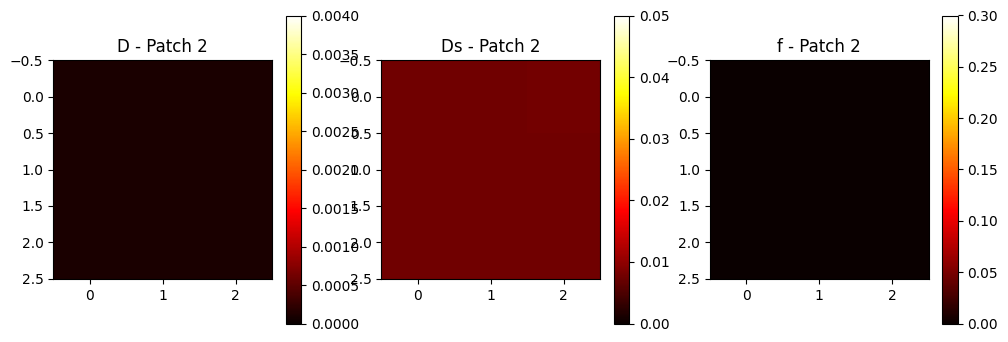

In [78]:
import matplotlib.pyplot as plt

# Take one patch
patch_idx = 2
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(D[patch_idx], cmap='hot', vmin=0, vmax=0.004)
plt.title(f'D - Patch {patch_idx}')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(Ds[patch_idx], cmap='hot', vmin=0, vmax=0.05)
plt.title(f'Ds - Patch {patch_idx}')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(f[patch_idx], cmap='hot', vmin=0, vmax=0.3)
plt.title(f'f - Patch {patch_idx}')
plt.colorbar()

plt.show()

In [59]:
# Make the model available under the name expected by the later notebook cells
model = cvae_model
model = model.to(device)
model.eval()
print(type(model).__name__)


PhysicsCVAE


In [57]:
# # Take mean of each 3×3 patch to get one value per patch
# D_mean = D.mean(axis=(1, 2))   # (total_patches,)
# Ds_mean = Ds.mean(axis=(1, 2))
# f_mean = f.mean(axis=(1, 2))

# plt.figure(figsize=(12, 4))
# plt.subplot(1, 3, 1)
# plt.scatter(coords[:, 0], coords[:, 1], c=D_mean, cmap='hot', s=1)
# plt.colorbar(label='D mean')
# plt.title('D spatial distribution')

# plt.subplot(1, 3, 2)
# plt.scatter(coords[:, 0], coords[:, 1], c=Ds_mean, cmap='hot', s=1)
# plt.colorbar(label='Ds mean')
# plt.title('Ds spatial distribution')

# plt.subplot(1, 3, 3)
# plt.scatter(coords[:, 0], coords[:, 1], c=f_mean, cmap='hot', s=1)
# plt.colorbar(label='f mean')
# plt.title('f spatial distribution')

# plt.show()

Reconstruction complete


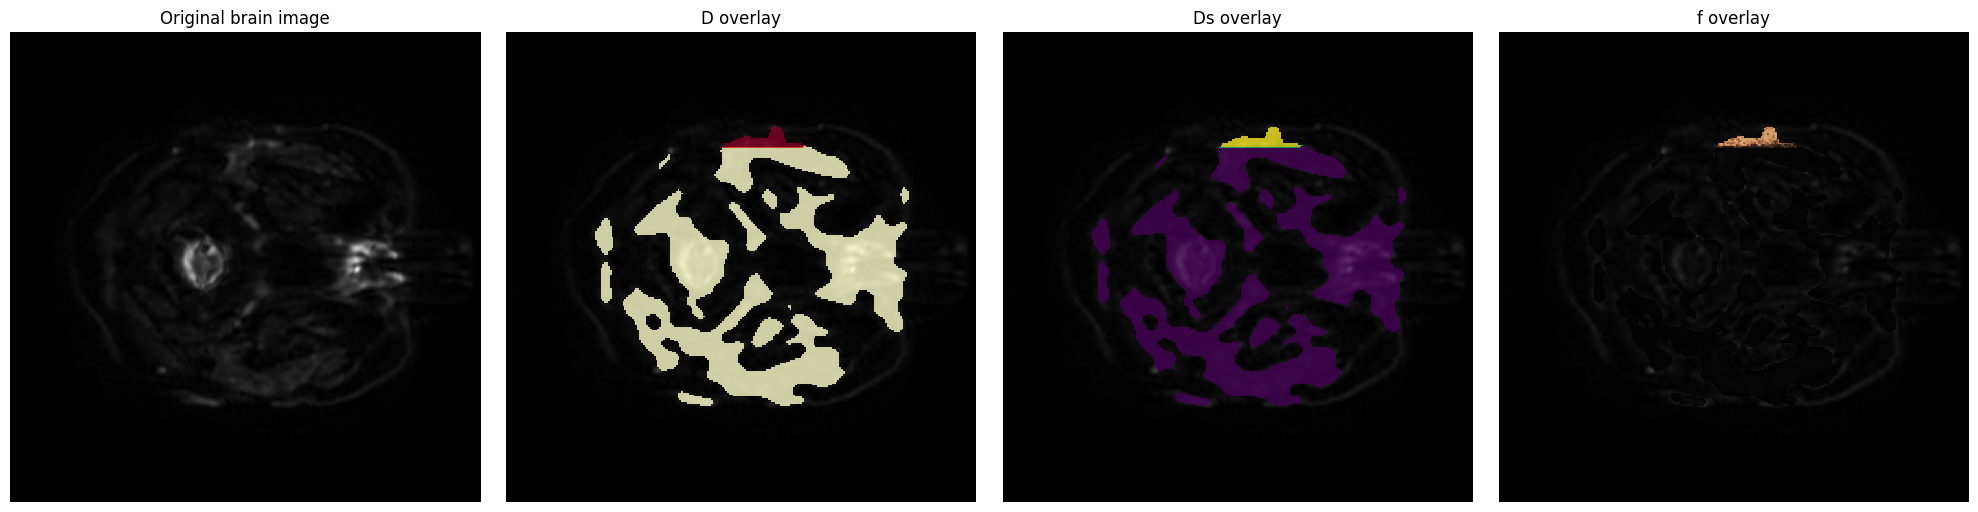

In [77]:
# Ensure coordinate mapping variables exist before the loop runs
if 'center_coords' not in globals():
    if 'center_coords_real' in globals():
        center_coords = center_coords_real
    elif 'center_coord' in globals():
        center_coords = center_coord[0] if isinstance(center_coord, list) and len(center_coord) > 0 else []
    else:
        center_coords = []
        try:
            for z in range(brain_msk.shape[0]):
                for y in range(brain_msk.shape[1]):
                    for x in range(brain_msk.shape[2]):
                        if brain_msk[z, y, x] > 0:
                            center_coords.append((z, y, x))
        except Exception:
            center_coords = []

# Reconstruct the parameter maps
D_map = np.zeros(brain_msk.shape)
Ds_map = np.zeros(brain_msk.shape)
f_map = np.zeros(brain_msk.shape)

pointer = 0
for i in range(x_batch.size(0)):
    if pointer >= len(center_coords):
        break
    z, y, x = center_coords[pointer]
    D_map[z, y, x] = D_vals[i]
    Ds_map[z, y, x] = Ds_vals[i]
    f_map[z, y, x] = f_vals[i]
    pointer += 1

print("Reconstruction complete")

# Use the B0 image as anatomical background
anat = np.array(b0_raw.get_fdata() if hasattr(b0_raw, 'get_fdata') else b0_raw)
if anat.ndim == 4:
    anat = anat[..., 0]

slice_idx = anat.shape[2] // 10
brain_bg = anat[..., slice_idx]
brain_mask_2d = (brain_msk[..., slice_idx] > 0) if brain_msk.ndim == 3 else (brain_msk > 0)

# Prepare masked 2D maps for the selected slice
D_slice = np.where(brain_mask_2d, D_map[..., slice_idx], np.nan)
Ds_slice = np.where(brain_mask_2d, Ds_map[..., slice_idx], np.nan)
f_slice = np.where(brain_mask_2d, f_map[..., slice_idx], np.nan)

# Make the overlays stand out strongly
D_slice = np.clip(D_slice, 0, np.nanpercentile(D_slice, 99))
Ds_slice = np.clip(Ds_slice, 0, np.nanpercentile(Ds_slice, 99))
f_slice = np.clip(f_slice, 0, np.nanpercentile(f_slice, 99))

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Panel 1: original image without masking
axes[0].imshow(brain_bg, cmap='gray')
axes[0].set_title('Original brain image')
axes[0].axis('off')

# Panels 2-4: overlays on the same anatomical image
for ax, (title, data, cmap, vmin, vmax) in zip(
    axes[1:],
    [
        ('D overlay', D_slice, 'YlOrRd', 0, np.nanpercentile(D_slice, 99)),
        ('Ds overlay', Ds_slice, 'viridis', 0, np.nanpercentile(Ds_slice, 99)),
        ('f overlay', f_slice, 'copper', 0, np.nanpercentile(f_slice, 99)),
    ],
):
    ax.imshow(brain_bg, cmap='gray')
    masked = np.where(brain_mask_2d, data, np.nan)
    ax.imshow(masked, cmap=cmap, alpha=0.8, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# **Test**

Finally, we instantiate the `PhysicsCVAE` model with the correct number of input channels (which is the number of b-values from your actual data) and train it using the `dataloader_real`.

### Updated Training Loop for GPU
Below is the modified training logic to ensure the `model` and `batches` are moved to the GPU memory.

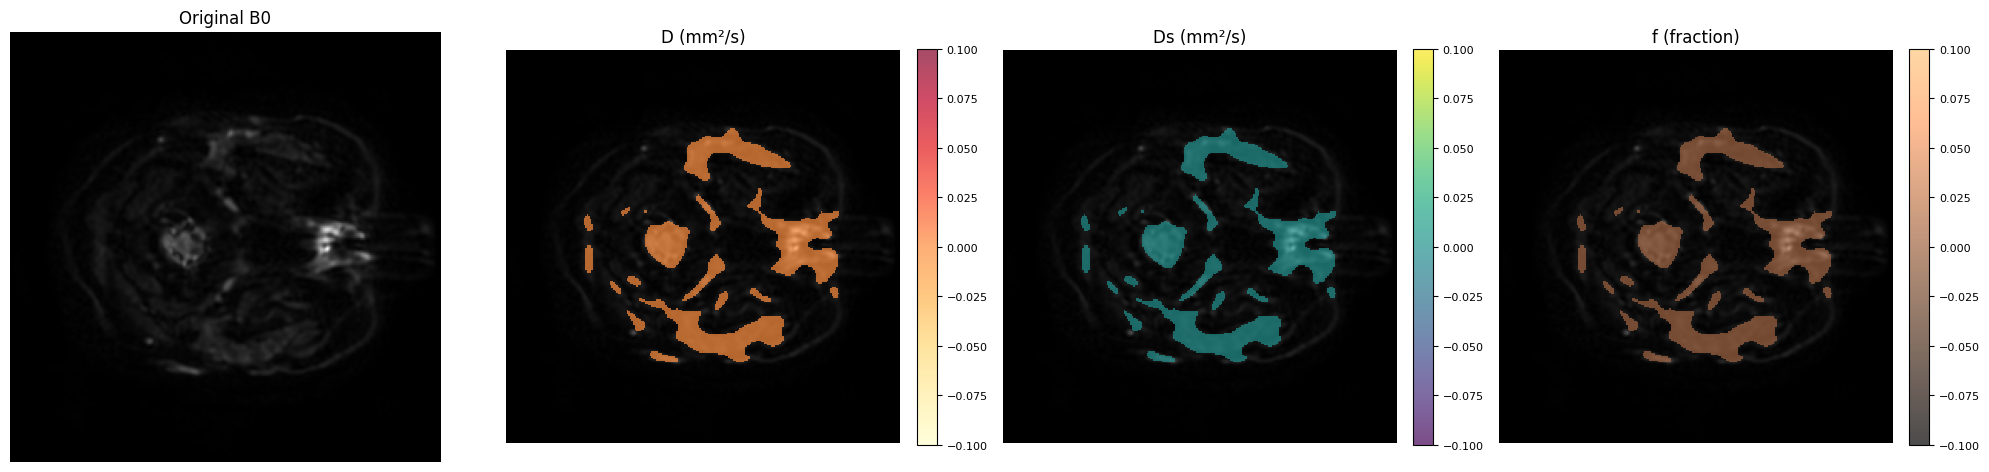

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# --- Reconstruct 2D maps (assuming scalar values) ---
D_map = np.zeros(brain_msk.shape)
Ds_map = np.zeros(brain_msk.shape)
f_map = np.zeros(brain_msk.shape)

pointer = 0
for i in range((x_batch.size(0))):  # or x_batch.size(0)
    if pointer >= len(center_coords):
        break
    z, y, x = center_coords[pointer]
    D_map[z, y, x] = D_vals[i]
    Ds_map[z, y, x] = Ds_vals[i]
    f_map[z, y, x] = f_vals[i]
    pointer += 1

# --- Load B0 and mask ---
# (Assuming you already have b0_raw and brain_msk)
anat = np.array(b0_raw.get_fdata() if hasattr(b0_raw, 'get_fdata') else b0_raw)
if anat.ndim == 4:
    anat = anat[..., 0]   # take first volume if 4D

# Choose a central slice
slice_idx = anat.shape[2] // 2
brain_bg = anat[..., slice_idx]
brain_mask_2d = (brain_msk[..., slice_idx] > 0) if brain_msk.ndim == 3 else (brain_msk > 0)

# Extract 2D slices and mask them
def mask_and_clip(data_3d, mask_2d, percentile=90):
    slice_2d = data_3d[..., slice_idx]
    masked = np.where(mask_2d, slice_2d, np.nan)
    # Clip to percentiles to avoid outliers
    vmin = 0
    vmax = np.nanpercentile(masked, percentile)
    return np.clip(masked, vmin, vmax)

D_slice = mask_and_clip(D_map, brain_mask_2d)
Ds_slice = mask_and_clip(Ds_map, brain_mask_2d)
f_slice = mask_and_clip(f_map, brain_mask_2d)

# --- Plotting ---
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

# Panel 1: original image
axes[0].imshow(brain_bg, cmap='gray')
axes[0].set_title('Original B0')
axes[0].axis('off')

# Panels 2-4: overlays
overlays = [
    ('D (mm²/s)', D_slice, 'YlOrRd'),
    ('Ds (mm²/s)', Ds_slice, 'viridis'),
    ('f (fraction)', f_slice, 'copper')
]

for ax, (title, data, cmap) in zip(axes[1:], overlays):
    # Show background
    ax.imshow(brain_bg, cmap='gray')
    # Show overlay
    im = ax.imshow(data, cmap=cmap, alpha=0.7, vmin=0, vmax=np.nanpercentile(data, 99))
    ax.set_title(title)
    ax.axis('off')
    # Add a colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()